In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('apex_retail_sales.csv')

In [9]:
df.head()

,order_id,date,customer_id,product_category,product_name,quantity,unit_price,total_price,payment_method
0,1979,2023-11-21 05:00:00,CUST_653,Garden,Shovel,3,760.69,2282.07,Cash
1,1568,2023-12-21 13:00:00,CUST_219,Tech,Smartphone,2,428.36,856.73,Debit Card
2,2679,2023-10-10 18:00:00,CUST_645,Home,Mirror,5,341.81,1709.04,PayPal
3,5692,2023-12-20 23:00:00,CUST_155,Tech,Smartphone,1,415.33,415.33,Credit Card
4,5716,2023-10-21 12:00:00,CUST_316,Furniture,Sofa,5,657.96,3289.79,Credit Card


In [10]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5050 non-null   int64  
 1   date              5050 non-null   str    
 2   customer_id       4711 non-null   str    
 3   product_category  5050 non-null   str    
 4   product_name      5050 non-null   str    
 5   quantity          5050 non-null   int64  
 6   unit_price        5050 non-null   float64
 7   total_price       5050 non-null   float64
 8   payment_method    4799 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 355.2 KB
None


In [11]:
print(df.describe())

          order_id     quantity   unit_price  total_price
count  5050.000000  5050.000000  5050.000000  5050.000000
mean   3497.039208     2.995644   501.270954  1498.101057
std    1444.697897     1.417285   288.642424  1187.531338
min    1000.000000     1.000000   -50.000000  -250.000000
25%    2243.250000     2.000000   249.240000   556.910000
50%    3496.500000     3.000000   501.130000  1177.770000
75%    4747.750000     4.000000   754.357500  2237.170000
max    5999.000000     5.000000   999.950000  4997.770000


In [12]:
print(df.duplicated().sum())

50


In [13]:
df[df['product_category'] == 'Tech']

,order_id,date,customer_id,product_category,product_name,quantity,unit_price,total_price,payment_method
1,1568,2023-12-21 13:00:00,CUST_219,Tech,Smartphone,2,428.36,856.73,Debit Card
3,5692,2023-12-20 23:00:00,CUST_155,Tech,Smartphone,1,415.33,415.33,Credit Card
12,4784,2023-12-01 10:00:00,CUST_921,Tech,Tablet,3,230.17,690.51,Credit Card
15,3435,2023-12-01 01:00:00,CUST_575,Tech,Headphones,5,541.68,2708.39,Debit Card
19,5979,2023-11-21 20:00:00,CUST_566,Tech,Tablet,3,180.04,540.11,Credit Card
...,...,...,...,...,...,...,...,...,...
5033,1492,2023-12-14 11:00:00,CUST_504,Tech,Smartphone,4,923.77,3695.06,Credit Card
5035,5437,2023-12-18 21:00:00,CUST_176,Tech,Smartphone,5,570.66,2853.31,Cash
5038,4478,2023-12-24 18:00:00,CUST_725,Tech,Headphones,1,241.33,241.33,Cash
5045,2504,2023-10-24 04:00:00,CUST_966,Tech,Headphones,5,235.84,1179.21,PayPal


In [14]:
# BORRA DUPLICADOS EXACTOS

df = df.drop_duplicates()

In [15]:
# BORRAR NEGATIVOS - SE FILTRA SOLO LOS QUE QUEREMOS DEJAR Y SE ASIGNA A LA VARIABLE

df = df[df['unit_price'] > 0 ]

In [16]:
# ESTANDARIZO CATEGORIAS (Tech, tech, Technology -> Tech)

# CAMBIO PRIMERA LETRA A MAYUSCULA
df['product_category'] = df['product_category'].str.capitalize()

# REEMPLAZO 'Technology' por 'Tech'
df['product_category'] = df['product_category'].replace('Technology', 'Tech')

In [17]:
# RELLENO LOS NULOS CON UNKNOWN

df['customer_id'] = df['customer_id'].fillna('Unknown')
df['payment_method'] = df['payment_method'].fillna('Unknown')

In [18]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 4975 entries, 0 to 5049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          4975 non-null   int64  
 1   date              4975 non-null   str    
 2   customer_id       4975 non-null   str    
 3   product_category  4975 non-null   str    
 4   product_name      4975 non-null   str    
 5   quantity          4975 non-null   int64  
 6   unit_price        4975 non-null   float64
 7   total_price       4975 non-null   float64
 8   payment_method    4975 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 388.7 KB
None


In [19]:
print(f'registros_finales: {len(df)}')
df.info()

registros_finales: 4975
<class 'pandas.DataFrame'>
Index: 4975 entries, 0 to 5049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          4975 non-null   int64  
 1   date              4975 non-null   str    
 2   customer_id       4975 non-null   str    
 3   product_category  4975 non-null   str    
 4   product_name      4975 non-null   str    
 5   quantity          4975 non-null   int64  
 6   unit_price        4975 non-null   float64
 7   total_price       4975 non-null   float64
 8   payment_method    4975 non-null   str    
dtypes: float64(2), int64(2), str(5)
memory usage: 388.7 KB


In [20]:
# AGRUPO POR CATEGORIA Y CALCULO EL PROMEDIO DE PRECIO

ticket_promedio = df.groupby('product_category')['total_price'].mean()

In [21]:
# MOSTRAMOS ORDENANDO DE MAYOR A MENOR PARA VER EL PRODCUTO MAS PREMIUM

print("Ticket promedio por categoria:")
print(ticket_promedio.sort_values(ascending=False))

Ticket promedio por categoria:
product_category
Garden        1543.390543
Appliances    1538.629871
Tech          1510.119911
Furniture     1479.143988
Home          1473.429496
Name: total_price, dtype: float64


<Axes: xlabel='product_category'>

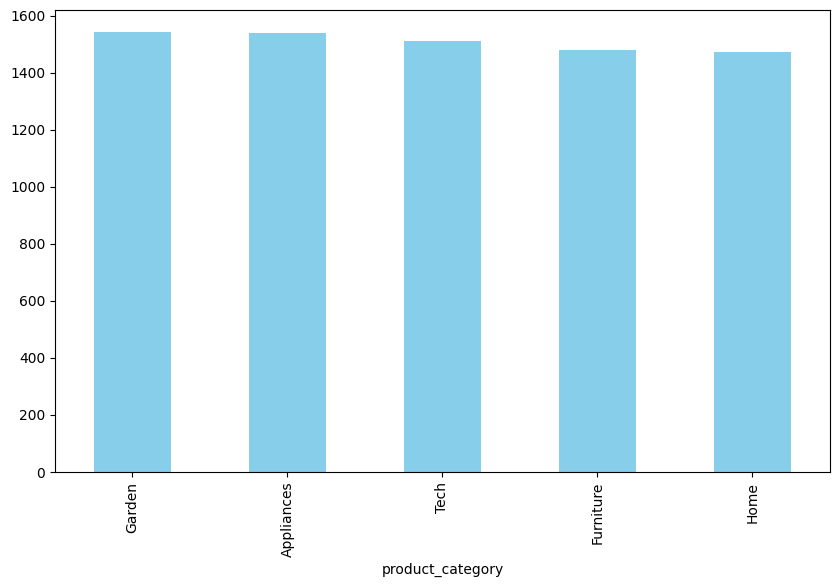

In [22]:
# CREO UN GRAFICO DE BARRAS PARA VISUALIZAR EL TICKET PROMEDIO POR CATEGORIA
ticket_promedio.sort_values(ascending=False).plot(kind='bar', color='skyblue', figsize=(10,6))

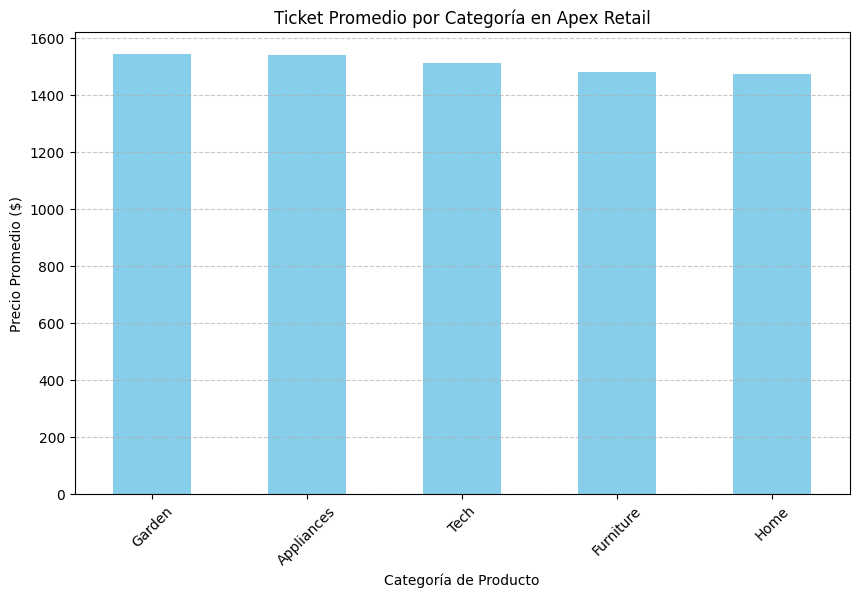

In [24]:
# AGREGO TITULO Y ETIQUETAS
ticket_promedio.sort_values(ascending=False).plot(kind='bar', color='skyblue', figsize=(10,6))
plt.title('Ticket Promedio por Categoría en Apex Retail')
plt.xlabel('Categoría de Producto')
plt.ylabel('Precio Promedio ($)')
plt.xticks(rotation=45) # Rotamos los nombres para que se lean bien
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [26]:
# CONVERTI COLUMNA DATE A FORMA DE FECHA REAL

df['date'] = pd.to_datetime(df['date'])

In [ ]:
# CREO UNA COLUMNA PARA LOS DIAS DE LA SEMANA Y EXTRAIGO DE DATE SOLO EL DIA

df['day_name'] = df['date'].dt.day_name()

In [ ]:
# CREO UNA COLUMNA HORA PARA SEPARLA DE LA FECHA

df['hour'] = df['date'].dt.hour

In [37]:
# VERIFICO QUE SE CREARON LAS COLUMNAS

df[['date', 'day_name', 'hour']].head(10)

,date,day_name,hour
0,2023-11-21 05:00:00,Tuesday,5
1,2023-12-21 13:00:00,Thursday,13
2,2023-10-10 18:00:00,Tuesday,18
3,2023-12-20 23:00:00,Wednesday,23
4,2023-10-21 12:00:00,Saturday,12
5,2023-11-24 14:00:00,Friday,14
6,2023-12-22 03:00:00,Friday,3
7,2023-11-01 15:00:00,Wednesday,15
8,2023-11-17 21:00:00,Friday,21
9,2023-10-30 22:00:00,Monday,22


In [ ]:
# VENTAS POR DIA

ventas_por_dia = df['day_name'].value_counts()
print(ventas_por_dia)

day_name
Thursday     736
Sunday       733
Friday       724
Wednesday    702
Tuesday      696
Monday       695
Saturday     689
Name: count, dtype: int64


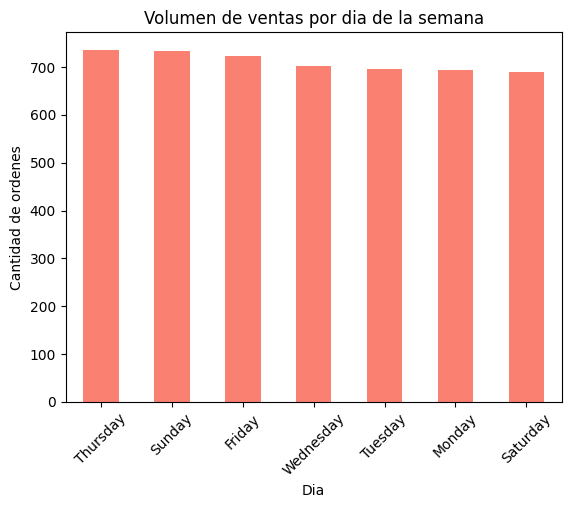

In [42]:
# GRAFICO DE VENTAS POR DIA

plt.Figure(figsize=(10,5))
ventas_por_dia.plot(kind='bar', color='salmon')
plt.title('Volumen de ventas por dia de la semana')
plt.xlabel('Dia')
plt.ylabel('Cantidad de ordenes')
plt.xticks(rotation=45)
plt.show()

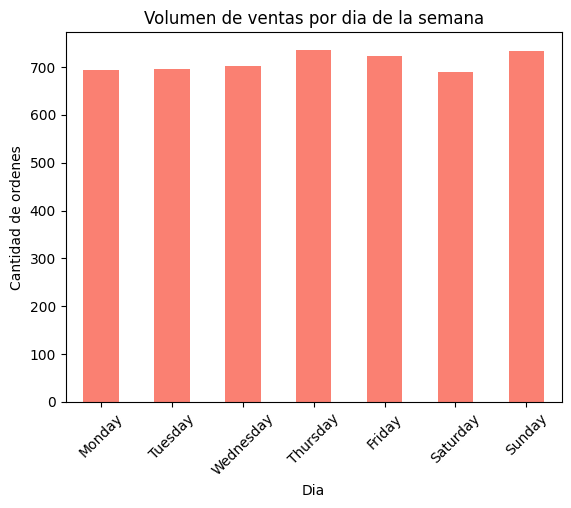

In [44]:
# ORDENO LOS DIAS EN EL GRAFICO

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# GUARDO LA REORGANIZACION DE DIAS PARA PODER GRAFICAR NUEVAMENTE

ventas_cronologicas = ventas_por_dia.reindex(orden_dias)

# GRAFICO

plt.Figure(figsize=(10,5))
ventas_cronologicas.plot(kind='bar', color='salmon')
plt.title('Volumen de ventas por dia de la semana')
plt.xlabel('Dia')
plt.ylabel('Cantidad de ordenes')
plt.xticks(rotation=45)
plt.show()

In [47]:
ventas_cronologicas.value_counts()
print(ventas_cronologicas)

day_name
Monday       695
Tuesday      696
Wednesday    702
Thursday     736
Friday       724
Saturday     689
Sunday       733
Name: count, dtype: int64


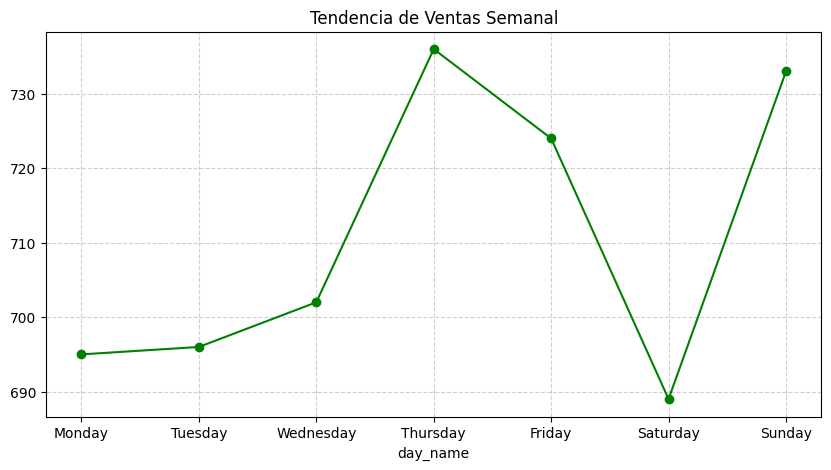

In [49]:
ventas_cronologicas.plot(kind='line', marker='o', color='green', figsize=(10,5))
plt.title('Tendencia de Ventas Semanal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()